In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/AMZN.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
1,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
3,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
4,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


In [2]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df = df.dropna()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [4]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,3774,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,2016-07-01 03:40:32.432432,59.408094,60.116390,58.669489,59.423925,9.185184e+07
min,2009-01-02 00:00:00,2.422000,2.505000,2.381500,2.428000,1.762600e+07
25%,2012-09-28 18:00:00,12.194500,12.300250,12.042125,12.146625,5.586350e+07
50%,2016-06-30 12:00:00,36.359499,36.489000,36.004000,36.322500,7.520600e+07
75%,2020-03-31 18:00:00,96.638248,97.750000,95.379747,96.663498,1.086060e+08
max,2023-12-29 00:00:00,186.570496,188.654007,184.839493,187.199997,1.166116e+09
std,NaN,54.918541,55.610783,54.233978,54.953769,6.057553e+07


In [5]:
# moving average
#SMA
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
#EMA
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()


In [6]:
# RSI
import ta

df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

In [7]:
# MACD
macd = ta.trend.MACD(df['Close'])

df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()

Visualization

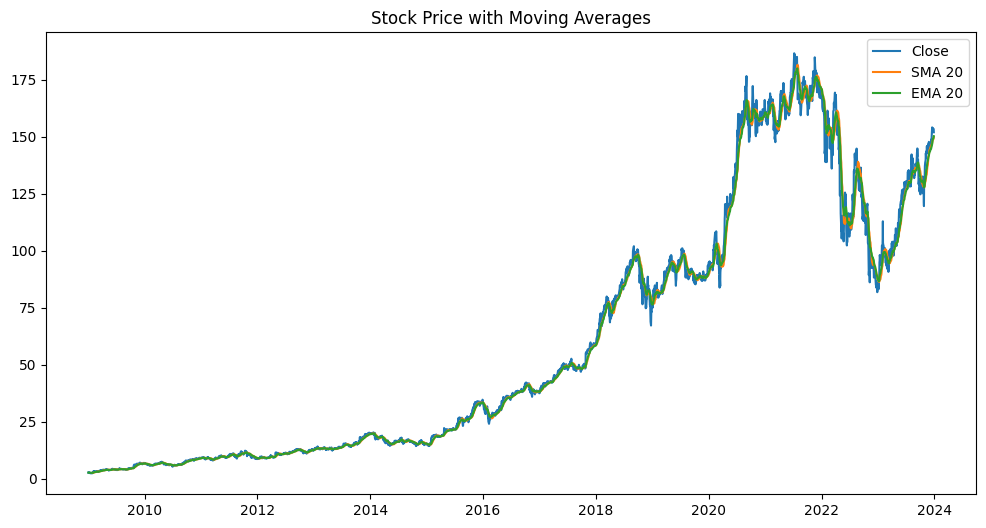

In [8]:
# Price and moving average

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['EMA_20'], label='EMA 20')

plt.legend()
plt.title("Stock Price with Moving Averages")
plt.show()

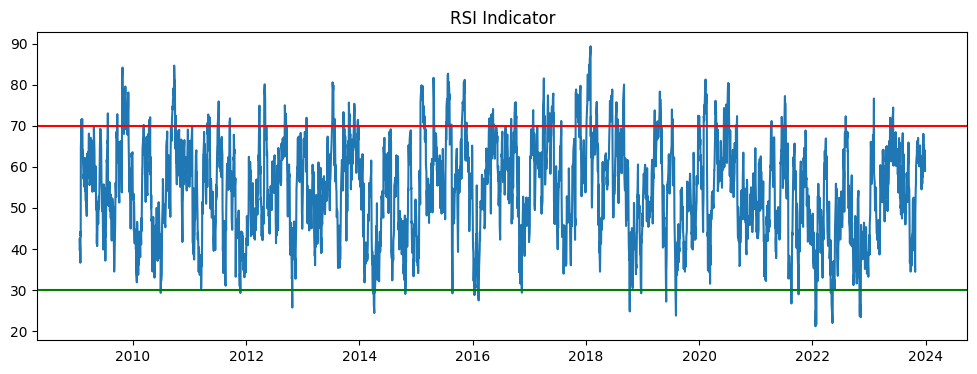

In [9]:
# RSI plot 
plt.figure(figsize=(12,4))

plt.plot(df['Date'], df['RSI'])

plt.axhline(70, color='red')
plt.axhline(30, color='green')

plt.title("RSI Indicator")
plt.show()

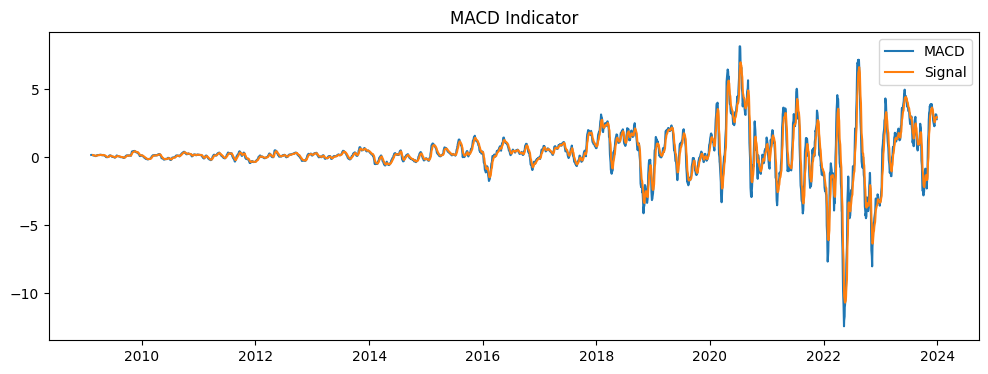

In [10]:
# MACD Plot
plt.figure(figsize=(12,4))

plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['MACD_signal'], label='Signal')

plt.legend()
plt.title("MACD Indicator")
plt.show()

In [11]:

df['returns'] = df['Close'].pct_change()
df['volatility'] = df['returns'].rolling(20).std()
df['log_returns'] = np.log(df['Close'] / df['Close'].shift(1))

In [12]:
df.tail()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI,MACD,MACD_signal,returns,volatility,log_returns
3769,2023-12-22,153.419998,154.350006,152.710007,153.770004,29514100,148.578999,141.2430,148.860492,64.115558,3.135958,2.873052,-0.002730,0.011908,-0.002734
3770,2023-12-26,153.410004,153.979996,153.029999,153.559998,25067200,148.863000,141.7154,149.293779,64.085644,3.118650,2.922172,-0.000065,0.011871,-0.000065
3771,2023-12-27,153.339996,154.779999,153.119995,153.559998,31434700,149.178500,142.1312,149.679133,63.860893,3.063965,2.950530,-0.000456,0.011782,-0.000456
3772,2023-12-28,153.380005,154.080002,152.949997,153.720001,27057000,149.531499,142.5694,150.031597,63.938728,2.989395,2.958303,0.000261,0.011678,0.000261
3773,2023-12-29,151.940002,153.889999,151.029999,153.100006,39823200,149.824000,143.0456,150.213350,59.012257,2.782032,2.923049,-0.009388,0.011946,-0.009433


In [13]:
df.to_csv("../data/AMZN_processed.csv")